TF-IDF matrix saved.
PPMI matrix saved.

Top 5 Nearest Neighbors:
پیٹرول: لیٹر, پمپ, ڈیزل, پمپس, قیمت
جنگ: بند, ایر, مذاکر, لبن, عارض
حکومت: طالب, وفاق, افغ, تحریک, عوام
پاکستان: فوج, طالب, افغ, پرچم, انڈین
افغانستان: 
امریکہ: ایر, مذاکر, درمی, اسرائیل, چین
عدالت: کورٹ, مقدمے, جج, ملزم, گرفتار
تیل: خام, گیس, قیمت, ہرمز, آبنائے
عمران: 
امن: پائیدار, غزہ, دیرپا, استحکام, بورڈ


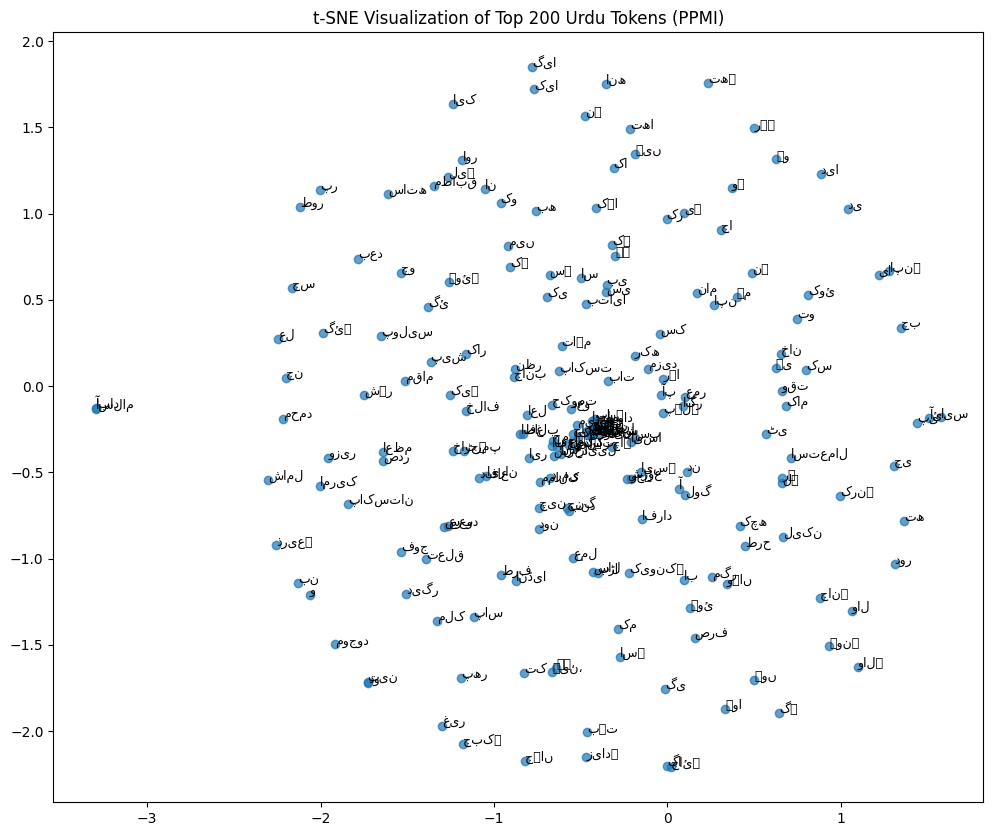

In [3]:
import numpy as np
import json
import re
from collections import Counter, defaultdict
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random
import json
import re
from typing import List, Tuple, Dict, Set
import os
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import math
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity


# 1. LOAD AND PREPROCESS DATA
def load_cleaned(file_path):
    docs = []
    with open(file_path, 'r', encoding='utf-8') as f:
        article = []
        for line in f:
            line = line.strip()
            if line.startswith("Article"):
                if article:
                    docs.append(article)
                article = []
            else:
                # Splitting by the '|' pipe character used in cleaned (1).txt
                tokens = [t.strip() for t in line.split('|') if t.strip()]
                article.extend(tokens)
        if article:
            docs.append(article)
    return docs

docs = load_cleaned("cleaned.txt")

# 2. BUILD VOCABULARY (Top 10,000)
all_tokens = [w for doc in docs for w in doc]
freq = Counter(all_tokens)

vocab_size = 10000
most_common = freq.most_common(vocab_size - 1)
vocab = {w: i for i, (w, _) in enumerate(most_common)}
vocab["<UNK>"] = len(vocab)
inv_vocab = {i: w for w, i in vocab.items()}

encoded_docs = [[vocab.get(w, vocab["<UNK>"]) for w in doc] for doc in docs]
V = len(vocab)
N = len(docs)

# 3. TF-IDF CALCULATION
df = Counter()
for doc in docs:
    unique_words = set(doc)
    for w in unique_words:
        if w in vocab:
            df[w] += 1

tfidf_matrix = np.zeros((N, V))
for i, doc in enumerate(docs):
    tf = Counter(doc)
    for w, count in tf.items():
        if w in vocab:
            # Standard TF-IDF formula
            idf = np.log(N / (1 + df[w]))
            tfidf_matrix[i][vocab[w]] = count * idf

np.save("tfidf_matrix.npy", tfidf_matrix)
print("TF-IDF matrix saved.")

# 4. PPMI CALCULATION
window_size = 5
co_matrix = np.zeros((V, V))

for doc in encoded_docs:
    for i, w in enumerate(doc):
        start = max(0, i - window_size)
        end = min(len(doc), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                co_matrix[w][doc[j]] += 1

total_sum = np.sum(co_matrix)
row_sums = np.sum(co_matrix, axis=1)
col_sums = np.sum(co_matrix, axis=0)

# Vectorized PPMI to avoid nested loops (faster)
ppmi_matrix = np.zeros((V, V))
for i in range(V):
    if row_sums[i] == 0: continue
    # Calculate PMI for the whole row
    p_i = row_sums[i] / total_sum
    p_j = col_sums / total_sum
    p_ij = co_matrix[i] / total_sum

    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.log2(p_ij / (p_i * p_j))

    ppmi_matrix[i] = np.maximum(0, pmi)

np.save("ppmi_matrix.npy", ppmi_matrix)
print("PPMI matrix saved.")

# 5. COSINE SIMILARITY & NEIGHBORS
def get_nearest_neighbors(word, matrix, top_n=5):
    if word not in vocab:
        return []
    idx = vocab[word]
    word_vec = matrix[idx].reshape(1, -1)
    sims = cosine_similarity(word_vec, matrix)[0]
    # Sort indices by similarity descending, excluding the word itself
    related_indices = sims.argsort()[::-1][1:top_n+1]
    return [inv_vocab[i] for i in related_indices]

query_words = ["پیٹرول", "جنگ", "حکومت", "پاکستان", "افغانستان", "امریکہ", "عدالت", "تیل", "عمران", "امن"]
print("\nTop 5 Nearest Neighbors:")
for word in query_words:
    neighbors = get_nearest_neighbors(word, ppmi_matrix)
    print(f"{word}: {', '.join(neighbors)}")

# 6. t-SNE VISUALIZATION
top_200_indices = [vocab[w] for w, _ in freq.most_common(200) if w in vocab]
X_tsne = ppmi_matrix[top_200_indices]

tsne = TSNE(n_components=2, random_state=42, init='pca')
X_2d = tsne.fit_transform(X_tsne)

plt.figure(figsize=(12, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

for i, idx in enumerate(top_200_indices):
    plt.annotate(inv_vocab[idx], (X_2d[i, 0], X_2d[i, 1]), fontsize=9)

plt.title("t-SNE Visualization of Top 200 Urdu Tokens (PPMI)")
plt.show()


Starting training on cpu...


Epoch 1: 100%|██████████| 6487/6487 [01:49<00:00, 59.25it/s, loss=3.04]


Epoch 1 Complete. Average Loss: 3.2647


Epoch 2: 100%|██████████| 6487/6487 [01:45<00:00, 61.70it/s, loss=2.94]


Epoch 2 Complete. Average Loss: 3.0127


...

Epoch 3 Complete. Average Loss: 2.9399


Epoch 4: 100%|██████████| 6487/6487 [01:44<00:00, 62.17it/s, loss=2.93]


Epoch 4 Complete. Average Loss: 2.8882


Epoch 5: 100%|██████████| 6487/6487 [01:43<00:00, 62.96it/s, loss=2.9]


Epoch 5 Complete. Average Loss: 2.8476
Embeddings saved to embeddings_w2v.npy


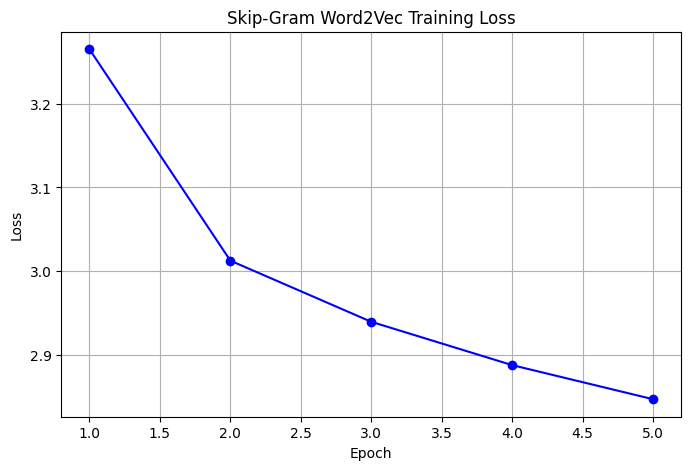

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- SKIP-GRAM WORD2VEC MODEL ---
class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        # V: Center word embeddings, U: Context word embeddings
        self.V = nn.Embedding(vocab_size, emb_dim)
        self.U = nn.Embedding(vocab_size, emb_dim)

        # Initialize weights (standard practice for better convergence)
        initrange = 0.5 / emb_dim
        self.V.weight.data.uniform_(-initrange, initrange)
        self.U.weight.data.uniform_(-0, 0) # Context matrix often starts at 0

    def forward(self, center, pos, neg):

        v = self.V(center)
        u_pos = self.U(pos)
        u_neg = self.U(neg)

        pos_score = torch.sum(v * u_pos, dim=1)
        pos_loss = torch.log(torch.sigmoid(pos_score))

        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        neg_loss = torch.sum(torch.log(torch.sigmoid(-neg_score)), dim=1)

        # Total Loss: -(pos_loss + neg_loss)
        return -torch.mean(pos_loss + neg_loss)

# --- PREPARE NOISE DISTRIBUTION ---
word_counts = np.array([freq.get(inv_vocab[i], 1) for i in range(V)])
noise_dist = torch.from_numpy(word_counts ** 0.75)
noise_dist = noise_dist / noise_dist.sum()

def get_negative_samples(batch_size, K, device):
    # Multinomial sampling for negative context words
    return torch.multinomial(noise_dist, batch_size * K, replacement=True).view(batch_size, K).to(device)

# --- PREPARE DATA ---
# Using a context window k=5 (symmetric)
pairs = []
for doc in encoded_docs:
    for i, center_word in enumerate(doc):
        start = max(0, i - 5)
        end = min(len(doc), i + 6)
        for j in range(start, end):
            if i != j:
                pairs.append((center_word, doc[j]))


pairs = np.array(pairs) # Faster slicing

# --- HYPERPARAMETERS ---
d = 100
k = 5
K = 10
lr = 0.001
batch_size = 512
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SkipGram(V, d).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

# --- TRAINING LOOP ---
losses = []
print(f"Starting training on {device}...")

for epoch in range(epochs):
    total_loss = 0
    np.random.shuffle(pairs)

    # Progress bar for each epoch
    pbar = tqdm(range(0, len(pairs), batch_size), desc=f"Epoch {epoch+1}")

    for i in pbar:
        batch = pairs[i : i + batch_size]
        if len(batch) < batch_size:
            continue

        center = torch.tensor(batch[:, 0], dtype=torch.long).to(device)
        pos = torch.tensor(batch[:, 1], dtype=torch.long).to(device)
        neg = get_negative_samples(batch_size, K, device)

        optimizer.zero_grad()
        loss = model(center, pos, neg)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / (len(pairs) // batch_size)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1} Complete. Average Loss: {avg_loss:.4f}")

# --- SAVE EMBEDDINGS ---
# Average of Center (V) and Context (U) matrices as per instructions
final_embeddings = (model.V.weight.data + model.U.weight.data) / 2
np.save("embeddings_w2v.npy", final_embeddings.cpu().numpy())
print("Embeddings saved to embeddings_w2v.npy")

# --- PLOT LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='-', color='b')
plt.title("Skip-Gram Word2Vec Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [8]:
import re
import json
import random
import os
from typing import List, Dict, Tuple, Set
from collections import defaultdict, Counter

# ==============================
# CONFIGURATION

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# POS Tags (11 tags — UNK is tag 11, total = 11 usable + UNK)
POS_TAGS = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'CONJ', 'POST', 'NUM', 'PUNC', 'UNK']

# NER BIO Tags
NER_TAGS = ['B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC', 'O']


# ==============================
# 1. LOAD DATA

def load_cleaned_sentences(filepath: str) -> List[List[str]]:
    """Load cleaned.txt and return list of tokenized sentences."""
    sentences = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('Article'):
                tokens = [t.strip() for t in line.split('|') if t.strip()]
                if tokens:
                    sentences.append(tokens)
    return sentences

def load_metadata(filepath: str) -> Dict:
    """Load metadata.json with topic information."""
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)


# ==============================
# 2. TOPIC CLASSIFICATION

# Map article IDs → broad topic based on metadata titles
TOPIC_KEYWORDS = {
    'Politics': [
        'وزیر اعظم', 'شہباز شریف', 'حکومت', 'کابینہ', 'وزارت', 'سیاست',
        'پارلیمنٹ', 'قومی اسمبلی', 'سینیٹ', 'انتخابات', 'سیاسی', 'پی ٹی آئی',
        'عمران خان', 'مریم نواز', 'نواز شریف', 'بلاول', 'فضل', 'وزیراعلیٰ',
        'گورنر', 'مارشل', 'فوج', 'آرمی', 'عاصم منیر', 'پارٹی', 'حزب'
    ],
    'Economy': [
        'پیٹرول', 'ڈیزل', 'قیمت', 'لیوی', 'سبسڈی', 'معیشت', 'ٹیکس',
        'بجٹ', 'آئی ایم ایف', 'خسارہ', 'مہنگائی', 'روپے', 'ڈالر', 'تیل',
        'گیس', 'بجلی', 'لوڈ شیڈنگ', 'زکوٰۃ', 'بینک', 'سرمایہ', 'تجارت',
        'درآمد', 'برآمد', 'سپیکٹرم', 'نیلامی', 'ریلویز', 'پی آئی اے'
    ],
    'International': [
        'ایران', 'جنگ', 'امریکہ', 'اسرائیل', 'آبنائے ہرمز', 'خلیج', 'چین',
        'آسٹریلیا', 'مصر', 'فلپائن', 'سری لنکا', 'ترکی', 'بین الاقوامی',
        'افغانستان', 'طالبان', 'سفارت', 'مذاکرات', 'ثالثی', 'جنگ بندی',
        'انڈیا', 'انڈین', 'سعودی', 'دبئی', 'ٹرمپ', 'مشرق وسطیٰ'
    ]
}

def classify_topic(tokens: List[str]) -> str:
    """Classify sentence topic using keyword matching."""
    text = ' '.join(tokens)
    scores = {topic: 0 for topic in TOPIC_KEYWORDS}
    for topic, keywords in TOPIC_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                scores[topic] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Politics'  # fallback

# ==============================
# 3. POS TAGGER

class UrduPOSTagger:
    """Rule-based POS tagger for Urdu with hand-crafted lexicon."""

    def __init__(self):
        self.lexicon = self._build_lexicon()
        self.suffix_rules = self._build_suffix_rules()

    def _build_lexicon(self) -> Dict[str, str]:
        lexicon = {}

        # ---------- NOUNS (200+ entries) ----------
        nouns = [
            'پاکستان', 'ملک', 'شہر', 'گھر', 'کام', 'زندگی', 'لوگ', 'وزیر', 'اعظم',
            'حکومت', 'عوام', 'قوم', 'صارفین', 'کسان', 'مسافر', 'وزارت', 'کابینہ',
            'تنخواہ', 'وسائل', 'بچت', 'مشکل', 'چیلنج', 'خطاب', 'پریس', 'کانفرنس',
            'فیصلہ', 'اعلان', 'منصوبہ', 'ہدایت', 'ریلویز', 'اکانومی', 'کلاس', 'ڈبے',
            'کرایہ', 'سبسڈی', 'امداد', 'بوجھ', 'اشیاء', 'ٹرانسپورٹ', 'موٹر', 'بائیکس',
            'گڈز', 'پیٹرول', 'ڈیزل', 'تیل', 'قیمت', 'لیوی', 'کسٹم', 'ڈیوٹی', 'مارجن',
            'منافع', 'پمپ', 'ریٹیل', 'صارف', 'درآمد', 'برآمد', 'مارکیٹ', 'سپلائی',
            'ٹینکر', 'آبنائے', 'ہرمز', 'جنگ', 'ایران', 'امریکہ', 'اسرائیل', 'خطہ',
            'توانائی', 'ایمرجنسی', 'ذخائر', 'حکمت', 'عملی', 'پالیسی', 'پروگرام',
            'آئی ایم ایف', 'بجٹ', 'خسارہ', 'اخراجات', 'اقدامات', 'کفایت', 'شعاری',
            'ملازمین', 'ریموٹ', 'چین', 'آسٹریلیا', 'مصر', 'فلپائن', 'سری لنکا',
            'ترکی', 'انقرہ', 'بیجنگ', 'سوشل', 'میڈیا', 'صحافی', 'تجزیہ', 'رپورٹ',
            'گیس', 'بجلی', 'پانی', 'روٹی', 'آٹا', 'چینی', 'دال', 'سبزی', 'گوشت',
            'سکول', 'ہسپتال', 'عدالت', 'پولیس', 'فوج', 'آرمی', 'نیوی', 'فضائیہ',
            'صوبہ', 'ضلع', 'تحصیل', 'گاؤں', 'محلہ', 'سڑک', 'پل', 'دروازہ', 'کمرہ',
            'کتاب', 'اخبار', 'رسالہ', 'ٹیلی ویژن', 'ریڈیو', 'انٹرنیٹ', 'موبائل',
            'ڈاکٹر', 'وکیل', 'انجینئر', 'استاد', 'طالب', 'علم', 'طالبہ', 'بچہ',
            'بچی', 'مرد', 'عورت', 'خاندان', 'والدین', 'ماں', 'باپ', 'بھائی', 'بہن',
            'دوست', 'دشمن', 'سربراہ', 'صدر', 'وزیر', 'سفیر', 'جج', 'جرنیل', 'سپاہی',
            'طاقت', 'کمزوری', 'امید', 'خوف', 'خوشی', 'غم', 'محبت', 'نفرت',
            'سال', 'ماہ', 'ہفتہ', 'دن', 'گھنٹہ', 'منٹ', 'صبح', 'شام', 'رات',
            'جنوری', 'فروری', 'مارچ', 'اپریل', 'مئی', 'جون', 'جولائی', 'اگست',
            'ستمبر', 'اکتوبر', 'نومبر', 'دسمبر', 'رمضان', 'عید', 'محرم', 'ربیع',
            'اقتصاد', 'تجارت', 'صنعت', 'زراعت', 'معاہدہ', 'سمجھوتہ', 'تنازع',
            'مذاکرات', 'گفتگو', 'بیان', 'پریس', 'نشست', 'اجلاس', 'سفر', 'دورہ',
            'حملہ', 'دفاع', 'سرحد', 'علاقہ', 'صوبہ', 'مرکز', 'ریاست', 'حکومت',
            'انتخاب', 'ووٹ', 'نشست', 'امیدوار', 'جماعت', 'اتحاد', 'اپوزیشن',
            'لیٹر', 'کلو', 'ٹن', 'میٹر', 'کلومیٹر', 'ایکڑ', 'ہیکٹر', 'فٹ', 'انچ',
            'رقم', 'تعداد', 'فیصد', 'نسبت', 'شرح', 'ڈالر', 'روپیہ', 'پیسہ', 'یوان',
        ]
        for w in nouns:
            lexicon[w] = 'NOUN'

        # ---------- VERBS (150+ entries) ----------
        verbs = [
            'کیا', 'کہا', 'گیا', 'ہوا', 'رہا', 'تھا', 'ہوں', 'ہو', 'ہیں', 'کر', 'کئے',
            'بڑھا', 'گئی', 'مقرر', 'وصول', 'جائے', 'لگائی', 'شامل', 'پہنچ', 'بن',
            'ہوگی', 'ہوگا', 'کرے', 'کروں', 'کریں', 'کرو', 'دی', 'دے', 'دوں', 'لے',
            'رکھا', 'رکھی', 'رکھیں', 'بنا', 'بنایا', 'بنائی', 'بنائے', 'چاہتا', 'چاہیے',
            'چاہوں', 'آئے', 'آئی', 'آیا', 'جائیے', 'جاؤ', 'جائیں', 'پڑے', 'پڑتا',
            'لگتا', 'لگے', 'لگائیں', 'دینا', 'لینا', 'کرنا', 'ہونا', 'رہنا', 'آنا',
            'جانا', 'دیکھنا', 'سوچنا', 'سمجھنا', 'ماننا', 'بتانا', 'پوچھنا', 'ملنا',
            'بڑھنا', 'گھٹنا', 'بند', 'کھلا', 'چلنا', 'روکنا', 'بچنا', 'خریدنا', 'بیچنا',
            'کہتا', 'کہتی', 'کہتے', 'ہوتا', 'ہوتی', 'ہوتے', 'کرتا', 'کرتی', 'کرتے',
            'گئے', 'آئے', 'دیا', 'لیا', 'کیے', 'ملا', 'ملی', 'ملے', 'چلا', 'چلی',
            'بولا', 'بولی', 'بولے', 'سنا', 'سنی', 'سنے', 'پڑھا', 'پڑھی', 'پڑھے',
            'لکھا', 'لکھی', 'لکھے', 'کھایا', 'پیا', 'سویا', 'اٹھا', 'بیٹھا', 'کھڑا',
            'بھیجا', 'بھیجی', 'بھیجے', 'لایا', 'لائی', 'لائے', 'پایا', 'پائی', 'پائے',
            'کھولا', 'بند', 'توڑا', 'جوڑا', 'رکھا', 'اٹھایا', 'گرایا', 'بنایا', 'مٹایا',
            'شروع', 'ختم', 'جار', 'بڑھا', 'گھٹا', 'تبدیل', 'بتایا', 'ظاہر', 'اعلان',
            'مسترد', 'منظور', 'قبول', 'رد', 'ثابت', 'مانا', 'تسلیم', 'انکار',
        ]
        for w in verbs:
            lexicon[w] = 'VERB'

        # ---------- ADJECTIVES (100+ entries) ----------
        adjectives = [
            'نیا', 'نئی', 'نئے', 'پرانا', 'پرانے', 'بڑا', 'بڑی', 'بڑے', 'چھوٹا', 'چھوٹی',
            'اچھا', 'اچھی', 'اچھے', 'برا', 'بری', 'برے', 'مہنگا', 'مہنگی', 'سستا', 'سستی',
            'آسان', 'مشکل', 'خوبصورت', 'گندا', 'صاف', 'گرم', 'ٹھنڈا', 'تیز', 'آہستہ',
            'زیادہ', 'کم', 'بہت', 'تھوڑا', 'پورا', 'خالی', 'بھرا', 'مکمل', 'ادھورا',
            'موجود', 'غائب', 'قریب', 'دور', 'بلند', 'پست', 'روشن', 'اندھیرا',
            'اہم', 'خاص', 'عام', 'ضروری', 'غیر ضروری', 'ممکن', 'ناممکن', 'واضح',
            'مبہم', 'درست', 'غلط', 'سچا', 'جھوٹا', 'مضبوط', 'کمزور', 'سخت', 'نرم',
            'تازہ', 'باسی', 'صحیح', 'خراب', 'ٹھیک', 'بیمار', 'صحت مند', 'خوش', 'ناخوش',
            'مطمئن', 'پریشان', 'حیران', 'خاموش', 'شور', 'تیز', 'سست', 'ذہین', 'بیوقوف',
            'امیر', 'غریب', 'مالدار', 'فقیر', 'کامیاب', 'ناکام', 'مشہور', 'گمنام',
            'پاکستانی', 'ایرانی', 'امریکی', 'چینی', 'ہندوستانی', 'افغان', 'عرب',
            'قومی', 'بین الاقوامی', 'علاقائی', 'مقامی', 'وفاقی', 'صوبائی', 'سرکاری',
            'نجی', 'سیاسی', 'معاشی', 'سماجی', 'دینی', 'مذہبی', 'فوجی', 'سفارتی',
            'تاریخی', 'ثقافتی', 'تعلیمی', 'صحت', 'عوامی', 'انسانی', 'بنیادی', 'خالص',
        ]
        for w in adjectives:
            lexicon[w] = 'ADJ'

        # ---------- ADVERBS (80+ entries) ----------
        adverbs = [
            'آج', 'کل', 'پرسوں', 'اب', 'تب', 'پہلے', 'بعد', 'آگے', 'پیچھے', 'اوپر',
            'نیچے', 'یہاں', 'وہاں', 'ادھر', 'اُدھر', 'کیوں', 'کیسے', 'جیسے', 'ویسے',
            'بالکل', 'بالترتیب', 'فوراً', 'آہستہ', 'تیزی', 'دھیرے', 'اچانک', 'آخر',
            'شاید', 'ضرور', 'ہمیشہ', 'کبھی', 'اکثر', 'ابھی', 'پھر', 'دوبارہ',
            'صرف', 'بھی', 'تقریباً', 'لگ بھگ', 'کم از کم', 'زیادہ سے زیادہ',
            'بالآخر', 'اچانک', 'فی الحال', 'بالخصوص', 'خاص طور پر', 'بطور', 'بالعموم',
        ]
        for w in adverbs:
            lexicon[w] = 'ADV'

        # ---------- PRONOUNS ----------
        pronouns = [
            'میں', 'تو', 'تم', 'آپ', 'وہ', 'یہ', 'ہم', 'اپنا', 'اپنی', 'اپنے',
            'اس', 'ان', 'انہوں', 'انھوں', 'انہیں', 'انھیں', 'مجھے', 'تجھے',
            'ہمیں', 'اسے', 'جو', 'جس', 'جن', 'کون', 'کیا', 'کس', 'آپ کو',
        ]
        for w in pronouns:
            lexicon[w] = 'PRON'

        # ---------- DETERMINERS ----------
        determiners = [
            'یہی', 'وہی', 'کوئی', 'کچھ', 'ہر', 'تمام', 'سب', 'اتنا', 'کتنا', 'جتنا',
            'دونوں', 'تینوں', 'چاروں', 'ایسا', 'ویسا', 'کیسا',
        ]
        for w in determiners:
            lexicon[w] = 'DET'

        # ---------- CONJUNCTIONS ----------
        conjunctions = [
            'اور', 'لیکن', 'مگر', 'اگر', 'کیونکہ', 'چونکہ', 'جبکہ', 'حالانکہ',
            'پھر', 'بلکہ', 'یا', 'یعنی', 'تاکہ', 'تاہم', 'البتہ', 'چنانچہ',
            'لہذا', 'اس لیے', 'کہ', 'جو', 'جب', 'جہاں', 'جیسے', 'گویا',
        ]
        for w in conjunctions:
            lexicon[w] = 'CONJ'

        # ---------- POSTPOSITIONS ----------
        postpositions = [
            'نے', 'کو', 'سے', 'کا', 'کی', 'کے', 'میں', 'پر', 'تک', 'لیے',
            'بارے', 'بغیر', 'ساتھ', 'ذریعے', 'دوران', 'مطابق', 'علاوہ',
            'بعد', 'قبل', 'پاس', 'خلاف', 'حق', 'واسطے', 'حوالے', 'ضمن',
        ]
        for w in postpositions:
            lexicon[w] = 'POST'

        # ---------- NUMBERS ----------
        numbers = [
            'ایک', 'دو', 'تین', 'چار', 'پانچ', 'چھ', 'سات', 'آٹھ', 'نو', 'دس',
            'گیارہ', 'بارہ', 'تیرہ', 'چودہ', 'پندرہ', 'سولہ', 'سترہ', 'اٹھارہ', 'انیس', 'بیس',
            'تیس', 'چالیس', 'پچاس', 'ساٹھ', 'ستر', 'اسی', 'نوے', 'سو', 'ہزار', 'لاکھ',
            'کروڑ', 'ارب', 'پہلا', 'دوسرا', 'تیسرا', 'چوتھا', 'پانچواں',
            '<NUM>',
        ]
        for w in numbers:
            lexicon[w] = 'NUM'

        # ---------- PUNCTUATION ----------
        for w in ['۔', '،', '؟', '!', ':', ';', '"', "'", '(', ')', '-', '...']:
            lexicon[w] = 'PUNC'

        return lexicon

    def _build_suffix_rules(self):
        return [
            (r'گار$', 'NOUN'),
            (r'کار$', 'NOUN'),
            (r'دان$', 'NOUN'),
            (r'خانہ$', 'NOUN'),
            (r'ستان$', 'NOUN'),
            (r'ت$', 'NOUN'),
            (r'ان$', 'NOUN'),
            (r'وں$', 'NOUN'),
            (r'نا$', 'VERB'),
            (r'تا$', 'VERB'),
            (r'تی$', 'VERB'),
            (r'تے$', 'VERB'),
            (r'گی$', 'VERB'),
            (r'گا$', 'VERB'),
            (r'یا$', 'VERB'),
            (r'ئی$', 'VERB'),
            (r'ی$', 'ADJ'),
            (r'انہ$', 'ADJ'),
        ]

    def tag(self, tokens: List[str]) -> List[Tuple[str, str]]:
        tagged = []
        for token in tokens:
            if token in self.lexicon:
                tagged.append((token, self.lexicon[token]))
            elif re.match(r'^[\d۰-۹]+([.,][\d۰-۹]+)?$', token):
                tagged.append((token, 'NUM'))
            elif token == '<NUM>':
                tagged.append((token, 'NUM'))
            else:
                pos = 'UNK'
                for pattern, tag in self.suffix_rules:
                    if re.search(pattern, token):
                        pos = tag
                        break
                if pos == 'UNK' and len(token) > 2:
                    pos = 'NOUN'   # default for unknown content words
                tagged.append((token, pos))
        return tagged

# 4. NER ANNOTATOR

class UrduNERAnnotator:
    """BIO-scheme NER annotator with gazetteer support."""

    def __init__(self):
        self.gazetteers = self._build_gazetteers()
        # Pre-tokenise multi-word gazetteer entries for fast lookup
        self._multi_word = self._index_multiword()

    def _build_gazetteers(self) -> Dict[str, Set[str]]:
        g: Dict[str, Set[str]] = {'PER': set(), 'LOC': set(), 'ORG': set(), 'MISC': set()}

        # ---------- PERSONS (50+ Pakistani personalities) ----------
        persons = [
            'شہباز شریف', 'مریم نواز', 'نواز شریف', 'عمران خان', 'بلاول بھٹو',
            'آصف علی زرداری', 'فضل الرحمان', 'مولانا فضل الرحمان', 'محسن نقوی',
            'علی محمد مہر', 'خرم شہزاد', 'محمد اورنگزیب', 'علی پرویز ملک',
            'تنویر ملک', 'مریم اورنگزیب', 'عبدالباسط', 'ارفع فیروز',
            'سیدہ لیلیٰ جعفری', 'وجاہت کاظمی', 'ریاض علی طوری', 'عارف علوی',
            'قمر جاوید باجوہ', 'ثمینہ علی', 'محمود خان اچکزئی', 'حنا ربانی کھر',
            'شیری رحمان', 'فواد چوہدری', 'اسد عمر', 'شوکت ترین',
            'عبدالقادر بلوچ', 'رانا ثناء اللہ', 'عطاء اللہ تڑ', 'پرویز الٰہی',
            'چوہدری پرویز الٰہی', 'حمزہ شہباز', 'حمزہ شریف', 'عباس شہباز',
            'سلطان راجہ', 'علی امین گنڈاپور', 'محمد علی سیف', 'فیصل واوڈا',
            'شیریں مزاری', 'مشاہد اللہ خان', 'خرم دستگیر', 'شہلا رضا',
            'نصرت بھٹو', 'بینظیر بھٹو', 'ذوالفقار علی بھٹو', 'محمد علی جناح',
            'لیاقت علی خان', 'ایوب خان', 'یحییٰ خان', 'ضیاء الحق', 'پرویز مشرف',
            'عاصم منیر', 'محمد یونس', 'سہیل آفریدی', 'علیمہ خان', 'ڈونلڈ ٹرمپ',
            'اویس لغاری', 'عارف حبیب', 'ڈیوڈ وارنر', 'رچرڈ برٹن', 'سلمان خان',
            'آشا بھوسلے', 'نہال ہاشمی', 'رنجیت سنگھ', 'جناح',
        ]
        g['PER'].update(persons)

        # ---------- LOCATIONS (50+) ----------
        locations = [
            'پاکستان', 'اسلام آباد', 'کراچی', 'لاہور', 'راولپنڈی', 'ملتان',
            'پشاور', 'کوئٹہ', 'گوجرانوالہ', 'فیصل آباد', 'سیالکوٹ', 'حیدرآباد',
            'سکھر', 'چنیوٹ', 'جھنگ', 'سرگودھا', 'بہاولپور', 'رحیم یار خان',
            'ڈیرہ غازی خان', 'مردان', 'ایبٹ آباد', 'سوات', 'گلگت', 'بلتستان',
            'مظفر آباد', 'میرپور', 'چترال', 'نوشہرہ', 'باجوڑ', 'بنوں', 'تونسہ',
            'آبنائے ہرمز', 'خلیج', 'مشرق وسطیٰ', 'ایران', 'امریکہ', 'اسرائیل',
            'چین', 'بیجنگ', 'آسٹریلیا', 'مصر', 'فلپائن', 'منیلا', 'سری لنکا',
            'کولمبو', 'ترکی', 'انقرہ', 'استنبول', 'دبئی', 'ابوظہبی', 'ریاض', 'دوحہ',
            'تہران', 'واشنگٹن', 'نئی دہلی', 'کابل', 'قطر', 'سعودی عرب', 'عمان',
            'ویانا', 'افغانستان', 'انڈیا', 'بنگلہ دیش', 'برطانیہ', 'جدہ', 'مکہ',
            'کشمیر', 'طورخم', 'پنجاب', 'سندھ', 'بلوچستان', 'خیبر پختونخوا',
        ]
        g['LOC'].update(locations)

        # ---------- ORGANIZATIONS (30+) ----------
        organizations = [
            'بی بی سی', 'بی بی سی اردو', 'آئی ایم ایف', 'اقوام متحدہ',
            'پاکستان تحریک انصاف', 'پی ٹی آئی', 'مسلم لیگ ن', 'پاکستان مسلم لیگ',
            'ن لیگ', 'پیپلز پارٹی', 'پاکستان پیپلز پارٹی', 'پی پی پی',
            'جمیعت علمائے اسلام', 'جے یو آئی', 'متحدہ قومی موومنٹ', 'ایم کیو ایم',
            'بلوچستان نیشنل پارٹی', 'عوامی نیشنل پارٹی', 'اے این پی',
            'پاکستان ریلویز', 'وزارت ریلویز', 'وزارت خزانہ', 'وزارت پیٹرولیم',
            'پیٹرولیم ڈویژن', 'اوگرا', 'آئل اینڈ گیس ریگولیٹری اتھارٹی',
            'پاکستان اسٹیٹ آئل', 'پی ایس او', 'شیل پاکستان', 'حکومت پاکستان',
            'وفاقی حکومت', 'پنجاب حکومت', 'سپریم کورٹ', 'لاہور ہائیکورٹ',
            'پاکستان آرمی', 'آئی ایس آئی', 'ایف آئی اے', 'پمز ہسپتال',
            'باچا خان یونیورسٹی', 'پی آئی اے', 'عارف حبیب گروپ',
        ]
        g['ORG'].update(organizations)

        # ---------- MISC ----------
        misc = [
            'روپے', 'ڈالر', 'پیٹرولیم لیوی', 'کسٹم ڈیوٹی', 'سبسڈی',
            'ٹارگیٹڈ سبسڈی', 'ایران جنگ', 'عارضی جنگ بندی', 'پریس کانفرنس',
            'گلوبل پیٹرول پرائسز', 'یوان', 'آسٹریلین ڈالر', 'سری لنکن روپے',
            'کلائمیٹ سپورٹ لیوی', 'ان لینڈ فریٹ ایکولائزیشن',
            'آئل مارکیٹنگ کمپنیاں', 'ایکسچینج ریٹ ایڈجسٹمنٹ', 'فائیو جی',
            'جی ایس پی پلس', 'ایل این جی', 'بورڈ آف پیس', 'نیٹ میٹرنگ',
            'نیٹ بلنگ', 'گلف نیٹو', 'سیون سسٹرز',
        ]
        g['MISC'].update(misc)

        return g

    def _index_multiword(self) -> Dict[str, List[Tuple[List[str], str]]]:
        """Build a dict keyed on first token → list of (token_list, entity_type)."""
        index: Dict[str, List[Tuple[List[str], str]]] = defaultdict(list)
        for etype, entries in self.gazetteers.items():
            for entry in entries:
                parts = entry.split()
                if len(parts) > 1:
                    index[parts[0]].append((parts, etype))
        # Sort longest first to prefer longer matches
        for key in index:
            index[key].sort(key=lambda x: -len(x[0]))
        return index

    def annotate(self, tokens: List[str]) -> List[Tuple[str, str]]:
        annotations: List[Tuple[str, str]] = []
        i = 0
        n = len(tokens)

        while i < n:
            token = tokens[i]
            matched = False

            # Try multi-word matches first (longest-match)
            if token in self._multi_word:
                for parts, etype in self._multi_word[token]:
                    end = i + len(parts)
                    if end <= n and tokens[i:end] == parts:
                        annotations.append((parts[0], f'B-{etype}'))
                        for p in parts[1:]:
                            annotations.append((p, f'I-{etype}'))
                        i = end
                        matched = True
                        break

            # Single-token gazetteer match
            if not matched:
                for etype, entries in self.gazetteers.items():
                    if token in entries:
                        annotations.append((token, f'B-{etype}'))
                        matched = True
                        i += 1
                        break

            if not matched:
                annotations.append((token, 'O'))
                i += 1

        return annotations

